# Music Recommendation System from Implicit Listening Data

### Neighborhood collaborative filtering, sparse similarity, and latent-factor models

`Python` · `Recommendation Systems` · `Collaborative Filtering` · `Matrix Factorization` · `MAP@K`

## Project overview

This project develops and evaluates a music recommendation workflow using implicit user–track interactions. It implements ranking metrics from scratch, constructs a sequence-aware holdout set, compares neighborhood-based recommenders, explores sparse similarity calculations, and studies latent user and track representations trained with SGD and alternating least squares.

The core objective is to understand how similarity choice, recommendation-list length, matrix representation, and optimization strategy affect ranking quality. The dataset contains interactions from **241 users** and more than **65,000 encoded tracks**. Track metadata are used for qualitative inspection of both personalized recommendations and learned item neighborhoods.

> **Data access:** the notebook was executed in Kaggle and expects the `recsys-tracks` dataset at the paths used in the loading cells.

In [1]:
from sklearn.preprocessing import LabelEncoder

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from typing import Callable, List

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as scs

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
ratings = pd.read_csv('https://raw.githubusercontent.com/murodzodam01/Music-Recommendation-System/refs/heads/main/data/music_dataset.csv')
ratings.head()

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404


In [6]:
tracks_info = pd.read_csv('https://github.com/murodzodam01/Music-Recommendation-System/raw/refs/heads/main/data/tracks_info.csv')
tracks_info.head()

,id,name,artists
0,0,What There Is,['a-ha']
1,1,I'll Play The Blues For You,['Albert King']
2,2,Breaking Up Somebody's Home,['Albert King']
3,3,Imma Be,['Black Eyed Peas']
4,4,Boom Boom Pow,['Black Eyed Peas']


## Evaluation metric: MAP@K

Recommendation quality is measured with Mean Average Precision at $K$:

$$
MAP@K = \frac{1}{N} \sum_{u=1}^{N} AP_u@K
$$

$$
AP_u@K = \frac{1}{\min(K,n_u)} \sum_{i=1}^{K} r_u(i)\,P_u@i
$$

$$
P_u@k = \frac{1}{k}\sum_{j=1}^{k}r_u(j)
$$

where:

- $N$ is the number of evaluated users;
- $n_u$ is the number of relevant tracks for user $u$ in the holdout set;
- $r_u(i)$ equals 1 when the track at rank $i$ is relevant and 0 otherwise;
- $P_u@i$ is precision calculated through rank $i$.

MAP@K rewards models that place relevant tracks near the top of each recommendation list, making it more informative than an unordered hit count.

### Metric implementation and validation

The metric is implemented directly to make the ranking calculation explicit. A small deterministic example verifies the result before the function is used in model evaluation.

In [7]:
def mapk(relevant: List[List[int]], predicted: List[List[int]], k: int = 20):
    s3 = 0
    for u in range(1, len(relevant) + 1):
        s2 = 0
        for i in range(1, k + 1):
            s1 = 0
            for j in range(1, i + 1):
                s1 += int(predicted[u - 1][j - 1] in relevant[u - 1])
            s2 += int(predicted[u - 1][i - 1] in relevant[u - 1]) * s1/i
        s3 += s2/min(k, len(relevant[u - 1]))
    return s3/len(relevant)

In [8]:
relevant = [
    [1, 7, 6, 2, 8],
    [1, 5, 4, 8],
    [8, 2, 5]
]

pred = [
    [8, 1, 5, 0, 7, 2, 9, 4],
    [0, 1, 8, 5, 3, 4, 7, 9],
    [9, 2, 0, 6, 8, 5, 3, 7]
]

assert round(mapk(relevant, pred, k=5), 4) == 0.4331 #checking whether function works as intended

## Sequence-aware train–test split

For every user, the final 50 interactions are reserved for evaluation and earlier interactions are used for training. Holdout tracks that never occur in the training data are removed because the collaborative models cannot learn representations for unseen items. This creates a realistic warm-item evaluation protocol while respecting the stored interaction order.

In [9]:
def train_test_split(ratings):
    train_ratings, test_ratings = [], []
    num_test_samples = 50

    # Build the training prefix for each user
    for userId, user_data in tqdm(ratings.groupby('userId')):
        train_ratings += [user_data[:-num_test_samples]]

    train_ratings = pd.concat(train_ratings).reset_index(drop=True)
    all_train_items = train_ratings['trackId'].unique()

    # Build the training prefix for each user
    # Keep only holdout tracks represented in training, because the models
    # cannot learn embeddings or collaborative signals for unseen items
    for userId, user_data in tqdm(ratings.groupby('userId')):
        test_items = user_data[-num_test_samples:]
        test_items = test_items[np.isin(test_items['trackId'], all_train_items)]
        test_ratings += [test_items]

    test_ratings = pd.concat(test_ratings).reset_index(drop=True)

    return train_ratings, test_ratings

In [10]:
train_ratings, test_ratings = train_test_split(ratings)

  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

### Identifier preparation

Track metadata are restricted to items available during training. User and track identifiers are then encoded into contiguous integer ranges so they can be used as matrix indices.

In [11]:
redundant_rows = np.where(~np.isin(tracks_info['id'], train_ratings['trackId'].unique()))[0]
tracks_info.drop(redundant_rows, inplace=True)
tracks_info = tracks_info.reset_index(drop=True)

In [12]:
def ids_encoder(ratings):
    users = sorted(ratings['userId'].unique())
    items = sorted(ratings['trackId'].unique())

    # create users and items encoders
    uencoder = LabelEncoder()
    iencoder = LabelEncoder()

    # fit users and items ids to the corresponding encoder
    uencoder.fit(users)
    iencoder.fit(items)

    return uencoder, iencoder

In [13]:
uencoder, iencoder = ids_encoder(train_ratings)
train_ratings['trackId'] = iencoder.transform(train_ratings['trackId'].tolist())
test_ratings['trackId'] = iencoder.transform(test_ratings['trackId'].tolist())
tracks_info['id'] = iencoder.transform(tracks_info['id'].tolist())

In [14]:
train_ratings.head()

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404


In [15]:
test_ratings.head()

,userId,trackId
0,0,57582
1,0,57802
2,0,57957
3,0,58174
4,0,59168


The remaining holdout tracks are grouped by user to create the relevance lists required by MAP@K.

In [16]:
test_relevant = []
test_users = []
for user_id, user_data in test_ratings.groupby('userId'):
    test_relevant += [user_data['trackId'].tolist()]
    test_users.append(user_id)

## Shared recommendation interface

`BaseModel` constructs the binary user–item interaction matrix and defines a common recommendation interface. The evaluation helper removes tracks already observed during training before returning each user's top-$K$ candidates.

In [17]:
class BaseModel:
    def __init__(self, ratings: pd.DataFrame):
        self.ratings = ratings
        self.n_users = len(np.unique(self.ratings['userId']))
        self.n_items = len(np.unique(self.ratings['trackId']))

        self.R = np.zeros((self.n_users, self.n_items))
        self.R[self.ratings['userId'], self.ratings['trackId']] = 1.

    def recommend(self, uid: int):
        """
        param uid: int - user's id
        return: [n_items] - vector of recommended items sorted by their scores in descending order
        """
        raise NotImplementedError

    def remove_train_items(self, preds: List[List[int]], k: int):
        """
        param preds: [n_users, n_items] - recommended items for each user
        param k: int
        return: np.array [n_users, k] - recommended items without training examples
        """
        new_preds = np.zeros((len(preds), k), dtype=int)
        for user_id, user_data in self.ratings.groupby('userId'):
            user_preds = preds[user_id]
            new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]

        return new_preds

    def get_test_recommendations(self, k: int):
        test_preds = []
        for user_id, user_data in self.ratings.groupby('userId'):
            test_preds.append(self.recommend(user_id))
        test_preds = self.remove_train_items(test_preds, k)
        return test_preds[test_users]

## Neighborhood collaborative filtering

The neighborhood model recommends tracks from users with similar listening histories. For a target user $u$, it first identifies a set of neighbors and then aggregates their implicit preferences.

Two binary-interaction similarity functions are compared:

1. **Normalized overlap** (named `pearson` in the implementation):

$$
s(u,v)=\frac{|I_u\cap I_v|}{\sqrt{|I_u|\,|I_v|}}
$$

Because the interaction values are binary and are not mean-centered, this function is mathematically closer to cosine-style normalized overlap than to conventional Pearson correlation.

2. **Jaccard similarity:**

$$
s(u,v)=\frac{|I_u\cap I_v|}{|I_u\cup I_v|}
$$

Here, $I_u$ denotes the set of tracks heard by user $u$. Neighbors are retained when their similarity exceeds $\alpha=0.02$:

$$
N(u)=\{v\in U\setminus\{u\}:s(u,v)>\alpha\}.
$$

Candidate items are scored with a similarity-weighted average:

$$
\hat r_{ui}=\frac{\sum_{v\in N(u)}s(u,v)r_{vi}}
{\sum_{v\in N(u)}|s(u,v)|}.
$$

### Vectorized similarity functions

Both similarities are implemented with NumPy operations over the full interaction matrix. The vectorized formulation avoids Python loops across users and provides the foundation for the neighborhood recommender.

In [18]:
def pearson(ratings: np.array, user_vector: np.array) -> np.array:
    return np.sum(ratings*user_vector, axis=1)/ np.sqrt(np.sum(ratings, axis=1) * np.sum(user_vector))
    pass


def jaccard(ratings: np.array, user_vector: np.array) -> np.array:
    return np.sum(ratings*user_vector, axis=1)/np.count_nonzero((ratings + user_vector > 0), axis=1)
    pass

### Neighborhood scoring

`User2User` filters users by the similarity threshold, excludes the target user from their own neighborhood, aggregates neighbor interactions, and returns track indices ordered by predicted relevance. The following small arrays provide sanity checks for similarity filtering, weighted scoring, sorting, and indexing behavior.

In [19]:
a = np.array([[1,0,1,1], [0,1,0,1], [1,0,1,0], [0,0,1,1], [1, 1,0, 1]])
b= np.array([1,1,0,1])
c = np.where(jaccard(a, b) > 0.05)[0]
inds = np.where(pearson(a, a[2]) > 0.2)[0]
inds = inds[inds!=2]
print(a[inds])
sim = pearson(a[inds], a[2])
#print(np.expand_dims(sim, axis=0))
print(sim)
print(np.matmul(sim,a[inds]))
print(np.argsort(-np.matmul(sim,a[inds])/np.sum(sim)))
#np.sort(np.sum(sim * self.ratings[uid], axis=1)/np.sum(sim, axis=1))

[[1 0 1 1]
 [0 0 1 1]
 [1 1 0 1]]
[0.81649658 0.5        0.40824829]
[1.22474487 0.40824829 1.31649658 1.72474487]
[3 2 0 1]


In [20]:
a = [[1,2,3],[2,3,4],[4,5,6]]
a[2]

[4, 5, 6]

In [21]:
class User2User(BaseModel):
    def __init__(self, ratings, similarity_func):
        super().__init__(ratings)

        assert similarity_func in [pearson, jaccard]

        self.similarity_func = similarity_func
        self.alpha = 0.02

    def similarity(self, user_vector: np.array):
        """
        user_vector: [n_items]
        """

        return np.where(self.similarity_func(self.R, user_vector) > self.alpha)[0]
        pass

    def recommend(self, uid: int):
        inds = self.similarity(self.R[uid])
        inds = inds[inds!=uid]
        sim = self.similarity_func(self.R[inds], self.R[uid])

        return np.argsort(-np.matmul(sim, self.R[inds])/np.sum(sim))
        pass

### Neighborhood benchmark

The normalized-overlap and Jaccard recommenders are evaluated across recommendation lengths from 1 to 49 and compared with a random-ranking baseline.

In [22]:
model1 = User2User(train_ratings, pearson)
model2 = User2User(train_ratings, jaccard)
test1_predicted = model1.get_test_recommendations(50)
test2_predicted = model2.get_test_recommendations(50)
test3_predicted = np.random.randint(0,max(train_ratings['trackId']), size=(len(test1_predicted) + 1,50))
pear = []
jac = []
random = []
for i in range(1,50):
    pear.append(mapk(test_relevant, test1_predicted, i))
    jac.append(mapk(test_relevant, test2_predicted, i))
    random.append(mapk(test_relevant, test3_predicted, i))

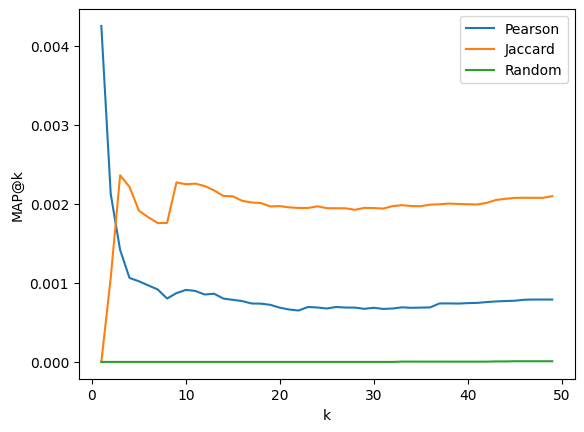

In [23]:
from matplotlib import pyplot as plt
plt.plot(np.arange(1, 50), pear,label='Pearson')
plt.plot(np.arange(1, 50), jac,label='Jaccard')
plt.plot(np.arange(1, 50), random,label='Random')
plt.xlabel("k")
plt.ylabel("MAP@k")
plt.legend()

### Neighborhood results

The benchmark reveals different ranking behavior by list length:

- normalized overlap is strongest at the first rank but declines rapidly as $K$ grows;
- Jaccard reaches its best performance around $K=3$–$4$ and remains stronger for most medium and long lists;
- random recommendations remain effectively at zero.

These results make Jaccard the more useful neighborhood method for practical multi-item recommendation lists, while normalized overlap is competitive when only the first result matters.

## Sparse similarity calculations

The interaction matrix is highly sparse, so dense similarity operations allocate unnecessary memory. Sparse CSR versions of both similarity functions are implemented and checked against the original neighborhood recommendations. The saved outputs show identical recommendation arrays for the dense and sparse similarity paths. A fully scalable production version would also store the base interaction matrix sparsely from construction and benchmark runtime and memory explicitly.

In [24]:
train_ratings

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404
...,...,...
129399,240,65424
129400,240,65436
129401,240,65480
129402,240,65515


In [25]:
scs.csr_matrix(train_ratings.values)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 258601 stored elements and shape (129404, 2)>

In [26]:
def pearson_sparse(ratings, user_vector) -> np.array:
    return np.squeeze(scs.csr_matrix(ratings.multiply(user_vector).sum(axis=1)/ np.sqrt(ratings.sum(axis=1)*(user_vector.sum()).transpose())).toarray())
    pass


def jaccard_sparse(ratings, user_vector) -> np.array:
    dtm = ratings + scs.csr_matrix(np.ones((ratings.shape[0], 1))) * user_vector > 0
    return np.squeeze(scs.csr_matrix(ratings.multiply(user_vector).sum(axis=1)).toarray().transpose()/(dtm.indptr[1:] - dtm.indptr[:-1]))
    pass

In [27]:
a = np.array([[1,0,1,1], [0,1,0,1], [1,0,1,0], [0,0,1,1], [1, 1,0, 1]])
b= np.array([1,1,0,1])
a1 =scs.csr_matrix(a)
b1 =scs.csr_matrix(b)
jaccard_sparse(scs.csr_matrix(a), scs.csr_matrix(b))
#sim1 = np.where(jaccard_sparse(scs.csr_matrix(a), scs.csr_matrix(b)) > 0.5)[0]
#sim = jaccard_sparse(scs.csr_matrix(a[sim1]), scs.csr_matrix(b))
#np.argsort(-np.matmul(sim, a[sim1])/np.sum(sim))

array([0.5       , 0.66666667, 0.25      , 0.25      , 1.        ])

In [28]:
class User2User_sparse(BaseModel):
    def __init__(self, ratings, similarity_func):
        super().__init__(ratings)

        assert similarity_func in [pearson_sparse, jaccard_sparse]

        self.similarity_func = similarity_func
        self.alpha = 0.02

    def similarity(self, user_vector: np.array):
        """
        user_vector: [n_items]
        """

        return np.where(self.similarity_func(scs.csr_matrix(self.R), scs.csr_matrix(user_vector)) > self.alpha)[0]
        pass

    def recommend(self, uid: int):
        inds = self.similarity(self.R[uid])
        inds = inds[inds!=uid]
        sim = self.similarity_func(scs.csr_matrix(self.R[inds]), scs.csr_matrix(self.R[uid]))
        return np.argsort(-np.matmul(sim, self.R[inds])/np.sum(sim))
        pass

In [29]:
model1_sparse = User2User_sparse(train_ratings, pearson_sparse)
model1_sparse.get_test_recommendations(50)

array([[ 9693,  7533,  6376, ...,  2537,  3217,   901],
       [24500,  2814, 33436, ..., 16414,  2941, 18070],
       [ 1073,  1019, 11493, ..., 24500, 24859,  2813],
       ...,
       [ 1019,   805,  9694, ...,   418,  6448, 14484],
       [  805,  7533,  4032, ...,  7793,   419,  6773],
       [18070, 33436,  2814, ..., 39597, 10792, 11950]])

In [30]:
model1= User2User(train_ratings, pearson)
model1.get_test_recommendations(50)

array([[ 9693,  7533,  6376, ...,  2537,  3217,   901],
       [24500,  2814, 33436, ..., 16414,  2941, 18070],
       [ 1073,  1019, 11493, ..., 24500, 24859,  2813],
       ...,
       [ 1019,   805,  9694, ...,   418,  6448, 14484],
       [  805,  7533,  4032, ...,  7793,   419,  6773],
       [18070, 33436,  2814, ..., 39597, 10792, 11950]])

## Qualitative recommendation inspection

A randomly selected user is used for a human-readable comparison between previously heard tracks, Jaccard-based recommendations, and held-out listening activity. The example shows a broad taste profile spanning classic pop, rock, contemporary pop, and Russian-language music. Several recommendations are stylistically plausible—such as Queen, Gloria Gaynor, The Beatles, and Stevie Wonder—while the list also demonstrates the difficulty of matching a diverse listener with interaction-only features.

In [31]:
user_id = np.random.randint(0, model1.n_users)

In [32]:
listened_tracks = train_ratings[train_ratings.userId == user_id].trackId[:15]

print('Already listened tracks:')

tracks_info.loc[listened_tracks][['name', 'artists']]

Already listened tracks:


,name,artists
27,La Camisa Negra,['Juanes']
145,(We're Gonna) Rock Around The Clock,['Bill Haley & His Comets']
234,Wind Of Change,['Scorpions']
373,Everyday,['Buddy Holly']
877,A Dios Le Pido,['Juanes']
3371,Na M' Agapas,['Sakis Rouvas']
3451,Quien Sera,['Lisa Ono']
4105,Get Around Town,['Revolver']
4255,Lemon Tree,"[""Fool's Garden""]"
4388,Amore Mio,['Bruno Ferrara']


In [33]:
preds = model2.get_test_recommendations(15)

print('Predicted tracks:')

tracks_info.loc[preds[user_id]][['name', 'artists']]

Predicted tracks:


,name,artists
44872,Might Not,"['Belly', 'The Weeknd']"
44880,Определенный интеграл,['Научно-технический рэп']
44879,Calma,"['Pedro Capó', 'Farruko']"
44878,Gucci Flip Flops,"['Bhad Bhabie', 'Snoop Dogg', 'Plies']"
44877,Yesterday,['The Beatles']
44876,Follow Me,"['Little Big', 'Tommy Cash']"
44875,Skibidi,['Little Big']
44874,Голоса,['Звонкий']
44873,Зын Зын,['Болат Нуримов']
44881,Первообразная,['Научно-технический рэп']


In [34]:
test_tracks = test_ratings[test_ratings.userId == user_id].trackId[:15]

print('Test-time tracks:')

tracks_info.loc[test_tracks][['name', 'artists']]

Test-time tracks:


,name,artists
38128,Kotik,"['Franziska Wiese', 'Александр Рыбак']"
38336,Mio fratello,"['Biagio Antonacci', 'Mario Incudine']"
38920,Wolf's Heart,"['Leo Rojas', 'Chantelle Barry']"
38940,Resurection (Robot's Outro),['PPK']
39530,Coco Jamboo,['Mr. President']
41064,"Malheur, malheur",['Maître Gims']
42038,Manchester y Liverpool,['Jeanette']
43017,SUBEME LA RADIO PORTUGUESE REMIX,"['Enrique Iglesias', 'Decemer Bueno', 'Anselmo..."
43400,Got My Mind Set On You,['George Harrison']
44216,Qué vendrá,['Zaz']


## Latent-factor recommendation

Latent-factor models represent each user and track with a lower-dimensional embedding:

$$
\hat r_{ui}=\langle p_u,q_i\rangle,
$$

where $p_u\in\mathbb{R}^d$ is the embedding of user $u$ and $q_i\in\mathbb{R}^d$ is the embedding of track $i$.

The regularized matrix-factorization objective is:

$$
L=\|R-PQ^\top\|_F^2+\lambda\left(\|P\|_F^2+\|Q\|_F^2\right).
$$

Two optimization approaches are explored. The SGD implementation updates embeddings only for observed interactions, whereas the ALS implementation solves against complete binary interaction rows and columns, treating unobserved entries as zeros. Their saved scores should therefore be interpreted as an exploratory comparison rather than as perfectly controlled optimization alternatives.

### Optimization strategies

The model supports stochastic gradient descent and alternating least squares. Both methods use regularization to constrain embedding magnitude and reduce overfitting.

### Stochastic gradient descent

For an observed interaction $(u,i)$, let

$$e_{ui}=r_{ui}-p_u^\top q_i.$$

The implementation applies the regularized updates

$$
p_u\leftarrow p_u+\eta\left(e_{ui}q_i-\lambda p_u\right),
$$

$$
q_i\leftarrow q_i+\eta\left(e_{ui}p_u-\lambda q_i\right),
$$

where $\eta$ is the learning rate.

### Alternating least squares

ALS holds one factor matrix fixed while solving for the other. With $I_d$ denoting the $d\times d$ identity matrix, the track update is

$$
q_i=\left(P^\top P+\lambda I_d\right)^{-1}P^\top R_{:i},
$$

and the user update is

$$
p_u=\left(Q^\top Q+\lambda I_d\right)^{-1}Q^\top R_{u:}.
$$

The code uses `numpy.linalg.solve` instead of forming an explicit matrix inverse, which is numerically preferable.

### Latent-factor implementation

`HiddenVars` initializes user and track embeddings, trains them with either SGD or ALS, and ranks tracks by the user–item dot product. The experiment evaluates a 64-dimensional ALS model and a 128-dimensional SGD model.

In [35]:
class HiddenVars(BaseModel):
    def __init__(self, ratings, dim=128, mode='sgd'):
        super().__init__(ratings)
        self.dim = dim

        assert mode in ['sgd', 'als']
        self.mode = mode

        self.P = np.random.normal(size=(self.n_users, dim))
        self.Q = np.random.normal(size=(self.n_items, dim))

        self.lr = 0.0003
        self.lamb = 0.05

    def fit(self, num_iters=5):
        train_error = []
        n_users, n_items = self.R.nonzero()
        for epoch in tqdm(range(num_iters)):

            if self.mode == 'sgd':
                for u, i in zip(n_users, n_items):
                    error = self.R[u, i] - np.dot(self.P[u, :], self.Q[i, :])
                    self.P[u, :] = self.P[u, :] + self.lr * (error * self.Q[i, :] - self.lamb * self.P[u, :])
                    self.Q[i, :] = self.Q[i, :] + self.lr * (error * self.P[u, :] - self.lamb * self.Q[i, :])
                    train_error.append(error)
                # Update latent factors with the selected optimization strategy
                pass

            elif self.mode == 'als':
                eye = np.eye(self.dim)
                for i in range(self.n_items):
                    first_matrix = np.dot(self.P.T, self.P) + self.lamb * eye
                    second_matrix =np.dot(self.P.T, self.R[:, i])
                    self.Q[i] = np.linalg.solve(first_matrix, second_matrix)
                for j in range(self.n_users):
                    first_matrix = np.dot(self.Q.T, self.Q) + self.lamb * eye
                    second_matrix =np.dot(self.Q.T, self.R[j])
                    self.P[j] = np.linalg.solve(first_matrix, second_matrix)
                # Update latent factors with the selected optimization strategy
                pass
        return self.P, self.Q, train_error

    def recommend(self, uid):
        pred_rating = self.P[uid] @ self.Q.T

        return np.argsort(pred_rating)[::-1]

### Latent-model evaluation

The saved experiments compare MAP@K for ALS and SGD against Jaccard collaborative filtering and random ranking. The raw per-interaction SGD errors are also plotted to inspect optimization behavior.

In [36]:
np.random.seed(0)
P_als,Q_als, train_error = HiddenVars(train_ratings, mode = 'als', dim = 64).fit()
pred_rating = P_als @ Q_als.T
test1_predicted = np.argsort(pred_rating)[::-1]
random_als = []
for i in range(1,50):
    random_als.append(mapk(test_relevant, test1_predicted, i))

  0%|          | 0/5 [00:00<?, ?it/s]

In [37]:
P,Q, train_error = HiddenVars(train_ratings, mode='sgd').fit(10)
pred_rating = P @ Q.T
test1_predicted = np.argsort(pred_rating)[::-1]
random_sgd = []
for i in range(1,50):
    random_sgd.append(mapk(test_relevant, test1_predicted, i))

  0%|          | 0/10 [00:00<?, ?it/s]

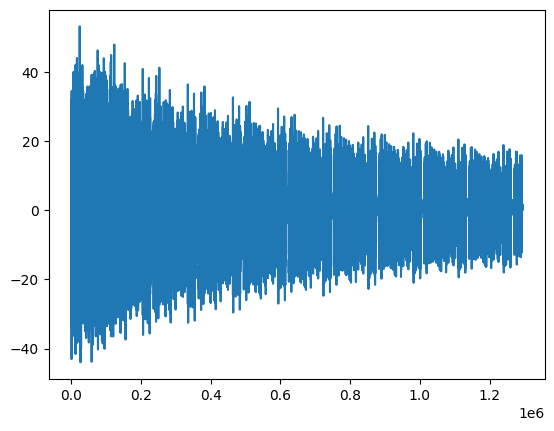

In [38]:
plt.plot(train_error)

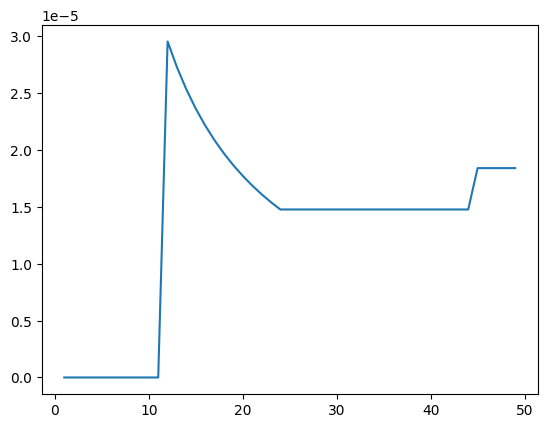

In [39]:
plt.plot(np.arange(1, 50), random_sgd)

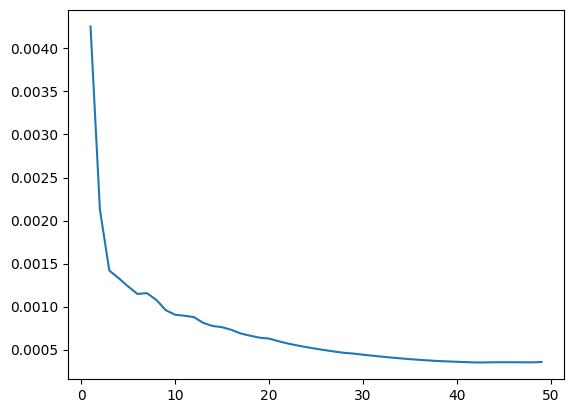

In [40]:
plt.plot(np.arange(1, 50), random_als)

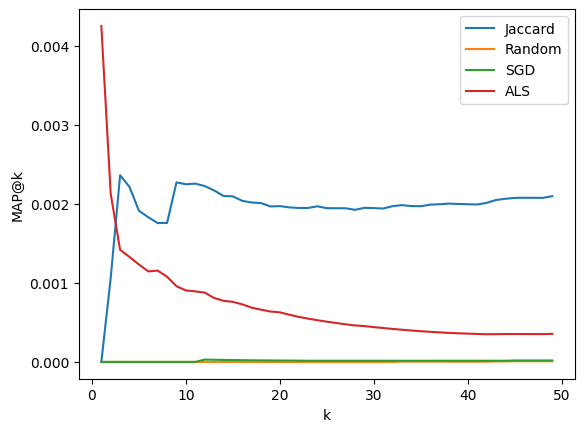

In [41]:
plt.plot(np.arange(1, 50), jac,label='Jaccard')
plt.plot(np.arange(1, 50), random,label='Random')
plt.plot(np.arange(1, 50), random_sgd,label='SGD')
plt.plot(np.arange(1, 50), random_als,label='ALS')
plt.xlabel("k")
plt.ylabel("MAP@k")
plt.legend()

### Latent-space findings

The stored results show that ALS is competitive at the very top of the ranking, but Jaccard produces stronger MAP@K for most recommendation-list lengths. The current SGD configuration stays close to the random baseline despite a narrowing error range, suggesting that its initialization, learning rate, objective, or evaluation protocol needs further tuning.

The learned ALS track space is inspected using **“Выхода нет”** by Сплин as an anchor. Several neighbors—including Leonard Cohen, Nick Cave & The Bad Seeds, and related Russian-language artists—are qualitatively plausible. However, many tracks share exactly the same displayed similarity, indicating limited separation in the learned representation. This supports treating the embedding analysis as exploratory rather than production-ready.

In [42]:
example_trackId = tracks_info[tracks_info.name == 'Выхода нет'].iloc[0].id

preds = Q_als @ Q_als[example_trackId]
preds = preds / np.sqrt((Q_als**2).sum(axis=1) + 1e-8)

track_idxs = preds.argsort()[::-1][:20]

In [43]:
similar_tracks = tracks_info.loc[track_idxs][['name', 'artists']]
similar_tracks['similarity'] = preds[track_idxs] / np.linalg.norm(Q_als[example_trackId])
similar_tracks

,name,artists,similarity
5512,Выхода нет,['Сплин'],1.000000
73,The Greatest,['Cat Power'],0.695187
24172,Медленная звезда,"['Би-2', 'Диана Арбенина']",0.686161
27732,Я верю,['Ляпис Трубецкой'],0.686161
5287,Home,['Edward Sharpe and the Magnetic Zeros'],0.686161
27641,il,['Jean-Michel Blais'],0.686161
1039,Get Up I Feel Like Being A Sex Machine,['James Brown'],0.686161
6757,Famous Blue Raincoat,['Leonard Cohen'],0.686161
7753,Nantes,['Barbara'],0.686161
26061,"Sing, Sing, Sing",['IKS Big Band'],0.686161


## Conclusions

This project compares recommendation approaches at three levels of complexity: neighborhood similarity, sparse computation, and latent-factor modeling.

### Main findings

- **Similarity choice depends on list length.** Normalized overlap performs best at rank 1, whereas Jaccard is stronger for most multi-item recommendation lists and peaks around $K=3$–$4$.
- **Personalization is meaningful.** Both neighborhood methods clearly outperform random ranking, confirming that shared listening histories contain useful recommendation signal.
- **Sparse and dense similarity paths are functionally consistent.** They return the same saved recommendation arrays, although a true scalability study still requires end-to-end sparse storage plus explicit runtime and memory benchmarks.
- **ALS is useful but not dominant.** It is competitive for the first recommendation, while Jaccard remains stronger across most larger values of $K$.
- **The stored SGD configuration is not effective.** Its ranking quality stays near random, so it should not be selected without changes to optimization and evaluation.
- **Qualitative inspection matters.** Personalized and embedding-based examples contain plausible musical relationships, but also expose broad tastes and tied latent similarities that aggregate metrics alone do not reveal.

### Recommended model

For this dataset and evaluation setup, **Jaccard user-to-user collaborative filtering** is the most reliable choice for a practical recommendation list. It combines stronger medium-depth MAP@K with transparent reasoning and straightforward sparse optimization. ALS remains a useful candidate when top-rank performance or reusable track embeddings are more important than broader-list accuracy.

### Limitations and next steps

- Store the interaction matrix as CSR throughout the full pipeline and record reproducible time and memory benchmarks.
- Evaluate latent models with a consistent top-$K$ construction, seen-item filtering, and objective across optimization methods.
- Add popularity, item-content, and hybrid baselines.
- Tune neighborhood thresholds, embedding dimensions, regularization, learning rate, and training iterations using a validation split.
- Report catalog coverage, novelty, diversity, and popularity bias alongside MAP@K.
- Use fixed qualitative examples and multiple random seeds to make results fully reproducible.